# Load Data

In [16]:
import polars as pl

training_parquet_path = "/Users/derek/UCLA_stats/statM148proj/training_new_data.parquet"
df = pl.read_parquet(training_parquet_path)

print(df.head(10))

shape: (10, 2)
┌────────────────────────┬─────────────────────────────────┐
│ id                     ┆ journey                         │
│ ---                    ┆ ---                             │
│ str                    ┆ list[struct[2]]                 │
╞════════════════════════╪═════════════════════════════════╡
│ -743958231 -117681777  ┆ [{2021-03-31 06:00:00 UTC,2}, … │
│ -659517787 729474696   ┆ [{2021-09-25 16:24:52 UTC,12},… │
│ -109130595 -1370315529 ┆ [{2021-03-27 18:03:58 UTC,4}, … │
│ -1345098175 317680138  ┆ [{2021-04-20 15:24:33 UTC,12},… │
│ -669651078 -259250089  ┆ [{2022-11-11 00:00:00 UTC,21},… │
│ 415764031 64077978     ┆ [{2021-09-18 01:32:20 UTC,12},… │
│ 266654673 -310369853   ┆ [{2022-12-04 19:35:19 UTC,1}, … │
│ 1563824867 872844052   ┆ [{2022-11-17 19:12:52 UTC,6}, … │
│ 1398643509 -1115193617 ┆ [{2021-01-15 06:00:00 UTC,2}, … │
│ 1713624658 2114639266  ┆ [{2022-10-27 10:38:49 UTC,12},… │
└────────────────────────┴─────────────────────────────────┘


# Feature Engineering

## Loading data with truncated observations

In [46]:
'''
Make sure to run build_truncated_data_codex.py to get the dataset with truncated observations
'''

from numpy import shape


file_path = "/Users/derek/UCLA_stats/statM148proj/truncated_data_codex.parquet"
df_truncated = pl.read_parquet(file_path)

sum(df_truncated['seen_ed_28'])
df_truncated.head(10)
shape(df_truncated)

(1430445, 77)

In [4]:
'''
Creating a more simple dataset for modeling, with only essential columns and dropping nulls.
This is for demonstration purposes, but we should probably discuss which features we want to keep
'''

file_path = "/Users/derek/UCLA_stats/statM148proj/truncated_data_codex.parquet"

essential_cols = [
    'label_order_shipped', 
    'observed_duration_days', 
    'last_stage', 
    'n_events_observed'
]

# Use scan_parquet for "Lazy" processing
df_simple = (
    pl.scan_parquet(file_path)
    .select(essential_cols)
    .drop_nulls()  # Polars equivalent of .dropna()
    .collect()     # This triggers the actual calculation
)

print(df_simple.head())

shape: (5, 4)
┌─────────────────────┬────────────────────────┬────────────────┬───────────────────┐
│ label_order_shipped ┆ observed_duration_days ┆ last_stage     ┆ n_events_observed │
│ ---                 ┆ ---                    ┆ ---            ┆ ---               │
│ i64                 ┆ f64                    ┆ str            ┆ i64               │
╞═════════════════════╪════════════════════════╪════════════════╪═══════════════════╡
│ 0                   ┆ 189.550595             ┆ Prospecting    ┆ 58                │
│ 0                   ┆ 188.826437             ┆ Prospecting    ┆ 20                │
│ 0                   ┆ 0.340721               ┆ Prospecting    ┆ 1                 │
│ 0                   ┆ 163.182278             ┆ Prospecting    ┆ 23                │
│ 0                   ┆ 12.429478              ┆ First Purchase ┆ 9                 │
└─────────────────────┴────────────────────────┴────────────────┴───────────────────┘


# Modeling

In [1]:
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 1. Prepare Features and Target
# one-hot encode 'last_stage' cat variable
df_ml = df_simple.to_dummies("last_stage")

# Define target (y) and features (X)
y = df_ml["label_order_shipped"].to_numpy() # TARGET: Label_order_shipped 
X = df_ml.drop("label_order_shipped").to_numpy() # FEATURES: all other cols

# Get feature names for later analysis
feature_names = df_ml.drop("label_order_shipped").columns

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

# 3. Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=10,      # Constraining depth helps with smoother CP profiles
    random_state=10,
    n_jobs=-1          # Uses all CPU cores
)

rf_model.fit(X_train, y_train)

# 4. Basic Evaluation
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nFeature Importances:")
for name, importance in zip(feature_names, rf_model.feature_importances_):
    print(f"{name}: {importance:.4f}")

NameError: name 'df_simple' is not defined

In [6]:
%pip install polars scikit-learn pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 979.4 kB/s  0:00:08 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 597.5 kB/s  0:00:34m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## CP for Numeric

In [38]:
# Select the first row from the test set as our 'Reference User'
# and convert it to a DataFrame for easy manipulation
reference_profile = pl.DataFrame([X_test[15]], schema=list(feature_names))

# Let's see what we are holding constant
print("Reference User Profile:")
print(reference_profile)


Reference User Profile:
shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ observed_ ┆ last_stag ┆ last_stag ┆ last_stag ┆ … ┆ last_stag ┆ last_stag ┆ last_stag ┆ n_events │
│ duration_ ┆ e_Apply   ┆ e_Credit  ┆ e_Discove ┆   ┆ e_First   ┆ e_Order   ┆ e_Prospec ┆ _observe │
│ days      ┆ for       ┆ Account   ┆ r         ┆   ┆ Purchase  ┆ Shipped   ┆ ting      ┆ d        │
│ ---       ┆ Credit    ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│           ┆ f64       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 120.46848 ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ 31.0     │
│ 4         ┆           ┆           ┆           ┆   ┆

/var/folders/v8/n6y_8qld08q40573457mfqpm0000gs/T/ipykernel_8491/1692102999.py:3: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  reference_profile = pl.DataFrame([X_test[15]], schema=list(feature_names))


In [9]:
print(min(df_simple['observed_duration_days']), max(df_simple['observed_duration_days']))

0.0 495.1209002048148


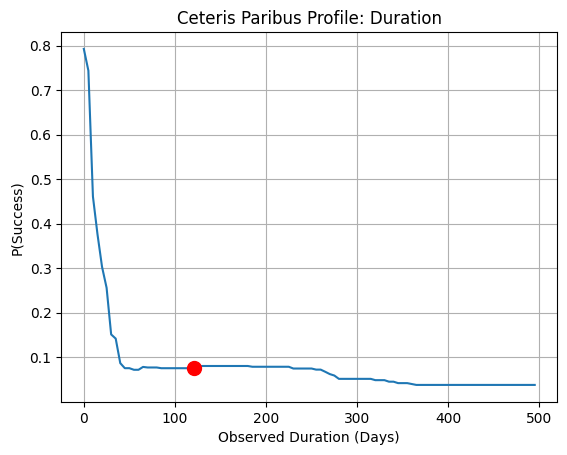

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of the numeric variable
duration_range = np.linspace(min(df_simple['observed_duration_days']), max(df_simple['observed_duration_days']), 100) 


# Create the CP dataset
cp_data_numeric = []
for val in duration_range:
    temp_row = reference_profile.clone()
    temp_row[0, "observed_duration_days"] = val
    cp_data_numeric.append(temp_row)

# Stack into one Polars DataFrame and predict
cp_df_numeric = pl.concat(cp_data_numeric)
cp_predictions = rf_model.predict_proba(cp_df_numeric.to_numpy())[:, 1]

# Plotting
actual_pred = rf_model.predict_proba(X_test[15:16])[:, 1]
actual_duration = reference_profile[0, "observed_duration_days"]
plt.plot(duration_range, cp_predictions, label="Random Forest")
plt.xlabel("Observed Duration (Days)")
plt.ylabel("P(Success)")
plt.title("Ceteris Paribus Profile: Duration")
plt.scatter(actual_duration, actual_pred, color='red', s=100, zorder=5, label="Reference User")
plt.grid(True)
plt.show()
actual_duration = reference_profile[0, "observed_duration_days"]




## CP for Categorical

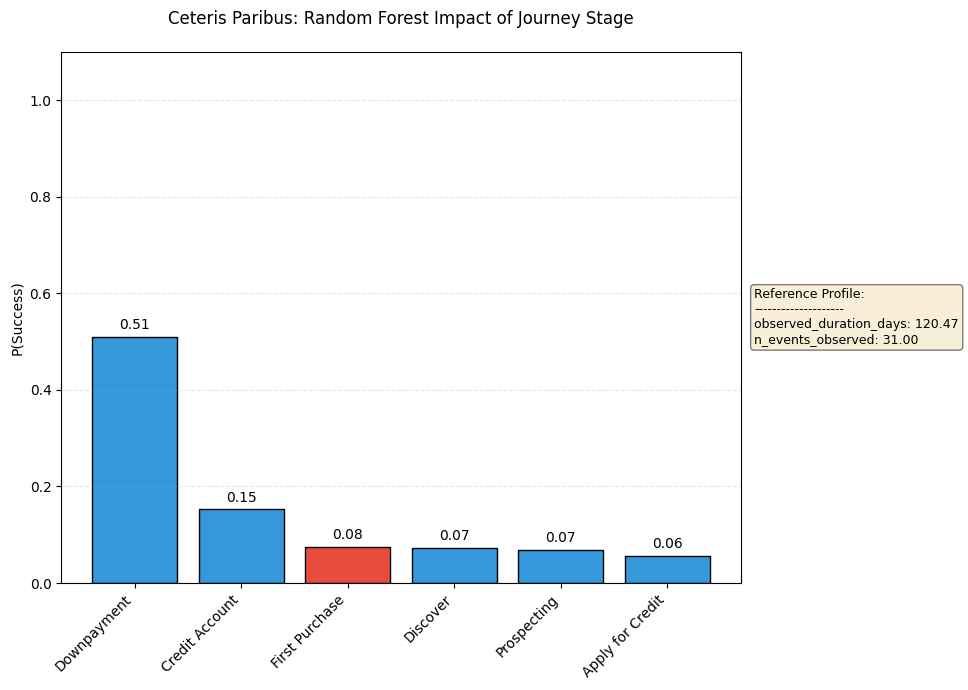

In [43]:
# 1. Identify columns that belong to 'last_stage' but EXCLUDE 'Order Shipped'
stage_cols = [c for c in feature_names if "last_stage" in c and "Order Shipped" not in c]

cp_results_cat = []

for stage in stage_cols:
    temp_row = reference_profile.clone()
    
    # Zero out all stages first to ensure a clean one-hot baseline
    all_stages = [c for c in feature_names if "last_stage" in c]
    for c in all_stages:
        temp_row[0, c] = 0
    
    # Set the current stage to 1
    temp_row[0, stage] = 1
    
    # Predict using Random Forest
    # Using .to_numpy() to match your existing rf_model.fit format
    prob = rf_model.predict_proba(temp_row.to_numpy())[:, 1][0]
    cp_results_cat.append({"Stage": stage.replace("last_stage_", ""), "Prob": prob})

# Convert to Polars and sort so the "ladder" effect is visible
cp_cat_df = pl.DataFrame(cp_results_cat).sort("Prob", descending=True)

import matplotlib.pyplot as plt

# 2. Plotting Setup
plt.figure(figsize=(12, 7))

# Highlight the stage "First Purchase" or the highest probability bar
colors = ['#e74c3c' if s == "First Purchase" else '#3498db' for s in cp_cat_df["Stage"]]

bars = plt.bar(cp_cat_df["Stage"], cp_cat_df["Prob"], color=colors, edgecolor='black')

# 3. Clean up the Details Text Box
# We exclude any target labels or stage dummies to show only constant numeric features
details = [f"{col}: {reference_profile[0, col]:.2f}" 
           for col in reference_profile.columns 
           if "last_stage" not in col and col != "label_order_shipped"]
details_text = "\n".join(details)

plt.text(1.02, 0.5, f"Reference Profile:\n{'-'*20}\n{details_text}", 
         transform=plt.gca().transAxes, fontsize=9, va='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Formatting
plt.ylabel("P(Success)")
plt.title("Ceteris Paribus: Random Forest Impact of Journey Stage", pad=20)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [32]:
print(reference_profile.columns)

['observed_duration_days', 'last_stage_Apply for Credit', 'last_stage_Credit Account', 'last_stage_Discover', 'last_stage_Downpayment', 'last_stage_First Purchase', 'last_stage_Order Shipped', 'last_stage_Prospecting', 'n_events_observed']


In [19]:
print(reference_profile)

shape: (1, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ observed_ ┆ last_stag ┆ last_stag ┆ last_stag ┆ … ┆ last_stag ┆ last_stag ┆ last_stag ┆ n_events │
│ duration_ ┆ e_Apply   ┆ e_Credit  ┆ e_Discove ┆   ┆ e_First   ┆ e_Order   ┆ e_Prospec ┆ _observe │
│ days      ┆ for       ┆ Account   ┆ r         ┆   ┆ Purchase  ┆ Shipped   ┆ ting      ┆ d        │
│ ---       ┆ Credit    ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ f64       ┆ ---       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│           ┆ f64       ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 120.46848 ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 1.0       ┆ 0.0       ┆ 0.0       ┆ 31.0     │
│ 4         ┆           ┆           ┆           ┆   ┆           ┆           ┆

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Define the Logistic Regression Pipeline
# We include a scaler because LR is a distance-based model
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        random_state=10, 
        max_iter=1000, 
        class_weight='balanced'
    ))
])

# 2. Train the model
log_reg_pipeline.fit(X_train, y_train)

# 3. Get Predictions
lr_pred_prob = log_reg_pipeline.predict_proba(X_test)[:, 1]
lr_pred = log_reg_pipeline.predict(X_test)

# 4. Comparative Evaluation
print("--- LOGISTIC REGRESSION PERFORMANCE ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_pred_prob):.4f}")
print(classification_report(y_test, lr_pred))

# 5. Extract Coefficients (Equivalent to Feature Importances)
# For LR, we look at the 'weights' assigned to each feature
coefs = log_reg_pipeline.named_steps['classifier'].coef_[0]

print("\nLogistic Regression Coefficients (Directional):")
lr_importances = sorted(zip(feature_names, coefs), key=lambda x: abs(x[1]), reverse=True)
for name, val in lr_importances:
    print(f"{name}: {val:.4f}")

--- LOGISTIC REGRESSION PERFORMANCE ---
ROC-AUC Score: 0.8754
              precision    recall  f1-score   support

           0       0.91      0.81      0.86    135483
           1       0.57      0.76      0.65     43459

    accuracy                           0.80    178942
   macro avg       0.74      0.79      0.76    178942
weighted avg       0.83      0.80      0.81    178942


Logistic Regression Coefficients (Directional):
observed_duration_days: -1.9007
last_stage_Downpayment: 0.9602
n_events_observed: 0.3814
last_stage_Apply for Credit: -0.3352
last_stage_Discover: -0.3310
last_stage_Credit Account: 0.2157
last_stage_Prospecting: -0.0921
last_stage_First Purchase: -0.0900
last_stage_Order Shipped: 0.0401


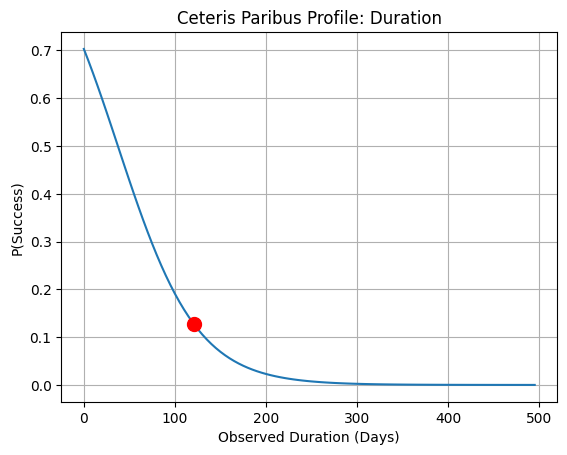

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of the numeric variable
duration_range = np.linspace(min(df_simple['observed_duration_days']), max(df_simple['observed_duration_days']), 100) 


# Create the CP dataset
cp_data_numeric = []
for val in duration_range:
    temp_row = reference_profile.clone()
    temp_row[0, "observed_duration_days"] = val
    cp_data_numeric.append(temp_row)

# Stack into one Polars DataFrame and predict
cp_df_numeric = pl.concat(cp_data_numeric)
cp_predictions = log_reg_pipeline.predict_proba(cp_df_numeric.to_numpy())[:, 1]

# Plotting
actual_pred = log_reg_pipeline.predict_proba(X_test[15:16])[:, 1]
actual_duration = reference_profile[0, "observed_duration_days"]
plt.plot(duration_range, cp_predictions, label="Logistic Regression", color='blue')
plt.xlabel("Observed Duration (Days)")
plt.ylabel("P(Success)")
plt.title("Ceteris Paribus Profile: Duration")
plt.scatter(actual_duration, actual_pred, color='red', s=100, zorder=5, label="Reference User")
plt.grid(True)
plt.show()
actual_duration = reference_profile[0, "observed_duration_days"]




In [33]:
# 1. Prep the stage columns (excluding the target label)
stage_cols = [c for c in feature_names if "last_stage" in c]

# Create a clean reference profile by dropping the target label
# This ensures the model only sees features
reference_features = reference_profile.drop("last_stage_Order Shipped")

cp_results_lr = []

for stage in stage_cols:
    # Clone the feature-only profile
    temp_row = reference_features.clone()
    
    # Reset all stage dummies to 0
    for c in stage_cols:
        temp_row[0, c] = 0
    
    # Set current stage to 1
    temp_row[0, stage] = 1
    
    # Predict using the pipeline (handles scaling)
    # Convert to pandas so the pipeline recognizes feature names
    prob = log_reg_pipeline.predict_proba(temp_row.to_pandas())[:, 1][0]
    
    cp_results_lr.append({
        "Stage": stage.replace("last_stage_", ""), 
        "Prob": prob
    })

# Convert to DataFrame and sort for a cleaner "ladder" visual
cp_df_lr = pl.DataFrame(cp_results_lr).sort("Prob", descending=True)

# 2. Plotting
plt.figure(figsize=(12, 7))

# Visual style: Highlight the highest probability stage
max_val = cp_df_lr["Prob"].max()
colors = ['#2ecc71' if p == max_val else '#3498db' for p in cp_df_lr["Prob"]]

bars = plt.bar(cp_df_lr["Stage"], cp_df_lr["Prob"], color=colors, edgecolor='black', alpha=0.8)

# 3. Reference Details Text Box (Excluding y-label)
details = []
for col in reference_features.columns:
    val = reference_features[0, col]
    # Only show numeric features that are "active" for this user
    if isinstance(val, (int, float)) and val != 0 and "last_stage" not in col:
        details.append(f"{col}: {val:.2f}")

details_text = "\n".join(details)
plt.text(1.02, 0.5, f"Reference Profile\n(Features Only):\n{'-'*20}\n{details_text}", 
         transform=plt.gca().transAxes, fontsize=10, va='center',
         bbox=dict(boxstyle='round', facecolor='ghostwhite', alpha=0.9))

# Formatting
plt.ylabel("Predicted Probability of Success")
plt.xlabel("Assumed Last Stage")
plt.title("Ceteris Paribus: Logistic Regression\nWhat if the user was in a different stage?", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

ColumnNotFoundError: "last_stage_Order Shipped" not found